In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import random
from torchvision.models import convnext_base, ConvNeXt_Base_Weights

# Set seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)



In [12]:
# Define transforms (basic transform to tensor)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05))
])

train_folder = "Training"
test_folder = "Testing"

# Load full training dataset
full_train_dataset = datasets.ImageFolder(root=train_folder, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]))

# Split into 80% train, 20% val
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(seed))
train_dataset.dataset.transform = transform  # Only affects training data

# Load test dataset
test_dataset = datasets.ImageFolder(root=test_folder, transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]))
# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 2296
Val size: 574
Test size: 394


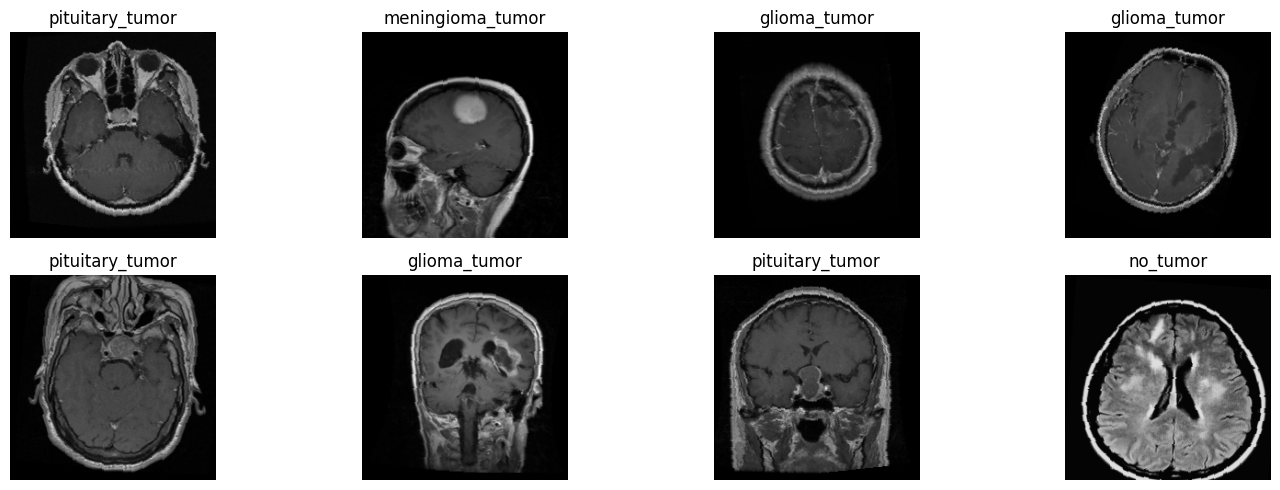

In [13]:
# Visualize some images
def show_images(dataset, n=8):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # From (C,H,W) to (H,W,C)
        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        plt.title(full_train_dataset.classes[label])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show some training images
show_images(train_dataset)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
weights = ConvNeXt_Base_Weights.DEFAULT
model = convnext_base(weights=weights)
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [18]:
# Define Model
def create_convnext():
    weights = ConvNeXt_Base_Weights.DEFAULT
    model = convnext_base(weights=weights)
    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.features[12:].parameters():
        param.requires_grad = True

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, 4)

    for param in model.classifier.parameters():
        param.requires_grad = True

    return model

model = create_convnext()

In [19]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=128, out_features=512, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=512, out_features=128, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
          (1): Permute()
          (2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
          (3): Linear(

In [ ]:
import matplotlib.pyplot as plt

def train_model(model, name, epochs=50, patience=10):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
            avg_val_loss = running_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
    
        print(f"{name} - Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"{name}_best.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping {name} at epoch {epoch+1}")
                break

    # Save final model
    torch.save(model.state_dict(), f"{name}_brain.pth")

    # Plot training and validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss Curve - {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{name}_loss_curve.png')
    plt.show()

    return model

trained_model = train_model(model, "ConvNeXt")

ConvNeXt - Epoch 1: Train Loss=1.3036, Val Loss=1.2397
ConvNeXt - Epoch 2: Train Loss=1.1783, Val Loss=1.1397
ConvNeXt - Epoch 3: Train Loss=1.0785, Val Loss=1.0447
ConvNeXt - Epoch 4: Train Loss=1.0005, Val Loss=0.9688
ConvNeXt - Epoch 5: Train Loss=0.9430, Val Loss=0.9154
ConvNeXt - Epoch 6: Train Loss=0.8958, Val Loss=0.8593
ConvNeXt - Epoch 7: Train Loss=0.8428, Val Loss=0.8190
ConvNeXt - Epoch 8: Train Loss=0.8095, Val Loss=0.7835
ConvNeXt - Epoch 9: Train Loss=0.7666, Val Loss=0.7471
ConvNeXt - Epoch 10: Train Loss=0.7499, Val Loss=0.7093
ConvNeXt - Epoch 11: Train Loss=0.7236, Val Loss=0.6911
ConvNeXt - Epoch 12: Train Loss=0.6974, Val Loss=0.6754
ConvNeXt - Epoch 13: Train Loss=0.6694, Val Loss=0.6478
ConvNeXt - Epoch 14: Train Loss=0.6726, Val Loss=0.6280
ConvNeXt - Epoch 15: Train Loss=0.6379, Val Loss=0.6155
ConvNeXt - Epoch 16: Train Loss=0.6382, Val Loss=0.6161
ConvNeXt - Epoch 17: Train Loss=0.6066, Val Loss=0.5967
ConvNeXt - Epoch 18: Train Loss=0.5986, Val Loss=0.5982
C

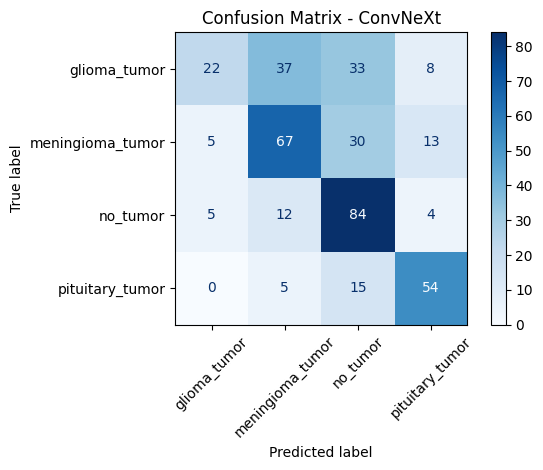

Test Accuracy: 0.5761
Test F1 Score (macro): 0.5591


(0.5761421319796954, 0.5590564448975172)

In [21]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, name, loader=test_loader):
    model = model.to(device)
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix.png")
    plt.show()

    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 Score (macro): {f1:.4f}")
    return acc, f1

evaluate_model(model, 'ConvNeXt')